# Predstavitev dobljenih podatkov

Pri tem sem si pomagala z dokumentacijo na [https//:pandas.pydata.org].

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

### Uvoz podatkov iz obeh csv datotek.

In [161]:
podatki_serije = pd.read_csv("shows/shows_community.csv")
podatki_epizode = pd.read_csv("shows/epizode_community.csv")
podatki_serije 

,Naslov,Povprecna_ocena_epizode,Stevilo_epizod,Stevilo_ocen_epizod,Stevilo_ocen_sezone,Povprecna_ocena_sezone,Minimalna_ocena,Maksimalna_ocena,Pozicija,ID,Prva_epizoda,Najnovejša_epizoda,Povprecna_dolzina_epizode,Stevilo_sezon
0,Breaking Bad,8.94,62,4525285,2646745.0,9.5,7.9,9.8,1,1396,2008-01-20,2013-09-29,48.31,5
1,Attack on Titan,9.12,89,4295339,732249.0,9.1,8.1,9.8,2,1429,2013-04-07,2022-04-04,23.99,4
2,Game of Thrones,8.74,73,5928154,2638292.0,9.2,4.0,9.9,3,1399,2011-04-17,2019-05-19,57.97,8
3,The Sopranos,8.61,86,921490,587404.0,9.2,7.7,9.7,4,1398,1999-01-10,2007-06-10,54.14,6
4,Avatar: The Last Airbender,8.60,61,531074,448701.0,9.3,6.8,9.9,5,246,2005-02-21,2008-07-19,24.66,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Hell on Wheels,8.22,57,43040,60052.0,8.3,7.3,8.9,246,1401,2011-11-06,2015-08-08,28.04,5
243,Derry Girls,8.19,19,31783,78646.0,8.5,7.6,9.1,247,76148,2018-01-04,2022-05-18,25.47,3
244,Justice League,8.05,52,55087,57533.0,8.5,7.3,9.3,248,1618,2001-11-17,2004-05-29,24.96,2
245,Phineas and Ferb,8.15,150,60809,68584.0,8.1,6.7,9.4,249,1877,2007-08-17,2026-01-16,13.27,5


In [162]:
podatki_epizode 

,vote_average,community_count,episode_number,season_number,air_date,runtime,id,pozicija,stevilo_epizod,ocena_serije
0,9.0,12437,1,1,2008-01-20,59,1396,1,62,9.5
1,8.7,11907,2,1,2008-01-27,49,1396,1,62,9.5
2,8.8,11764,3,1,2008-02-10,49,1396,1,62,9.5
3,8.5,11650,4,1,2008-02-17,49,1396,1,62,9.5
4,8.3,11558,5,1,2008-02-24,49,1396,1,62,9.5
...,...,...,...,...,...,...,...,...,...,...
22054,8.4,7,6,2,2009-02-22,27,2742,250,22,8.5
22055,8.3,7,7,2,2009-03-01,28,2742,250,22,8.5
22056,8.1,7,8,2,2009-03-08,25,2742,250,22,8.5
22057,8.1,7,9,2,2009-03-15,27,2742,250,22,8.5


## Po epizodah

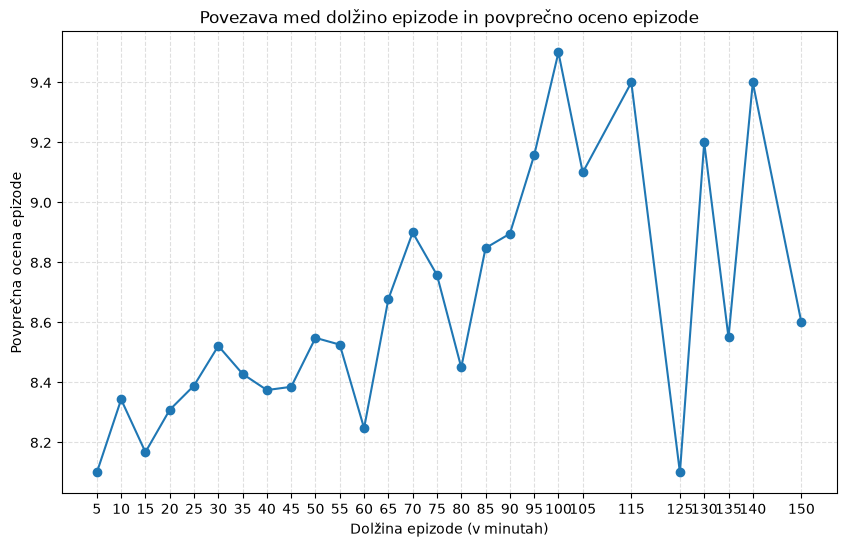

In [163]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .mean()
    .sort_index()
)

intervali = intervali.dropna()

plt.figure(figsize=(10, 6))
plt.title("Povezava med dolžino epizode in povprečno oceno epizode")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Povprečna ocena epizode")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.grid(True, linestyle="--", alpha=0.4)


Graf, ki prikazuje število epizod za določeno dolžino epizode. 

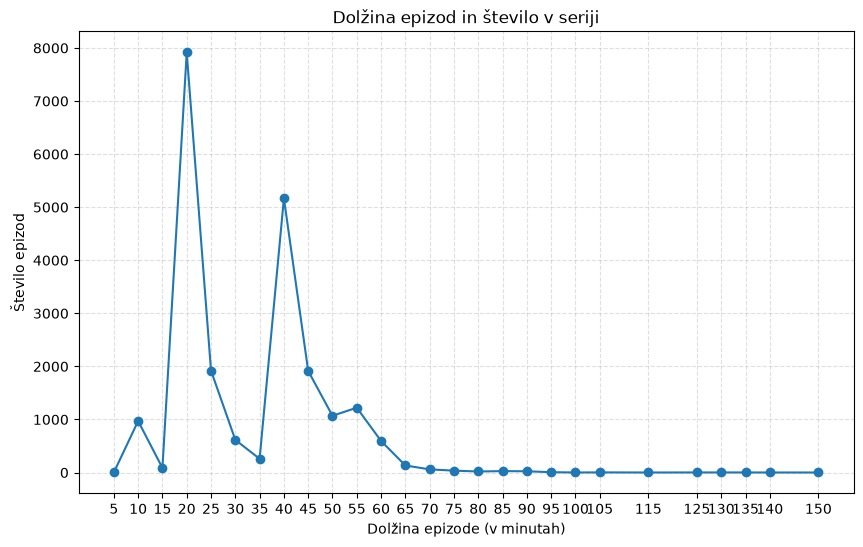

In [164]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .count()
    .sort_index()
)

intervali = intervali.dropna()

plt.figure(figsize=(10, 6))
plt.title("Dolžina epizod in število v seriji")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Število epizod")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.grid(True, linestyle="--", alpha=0.4)


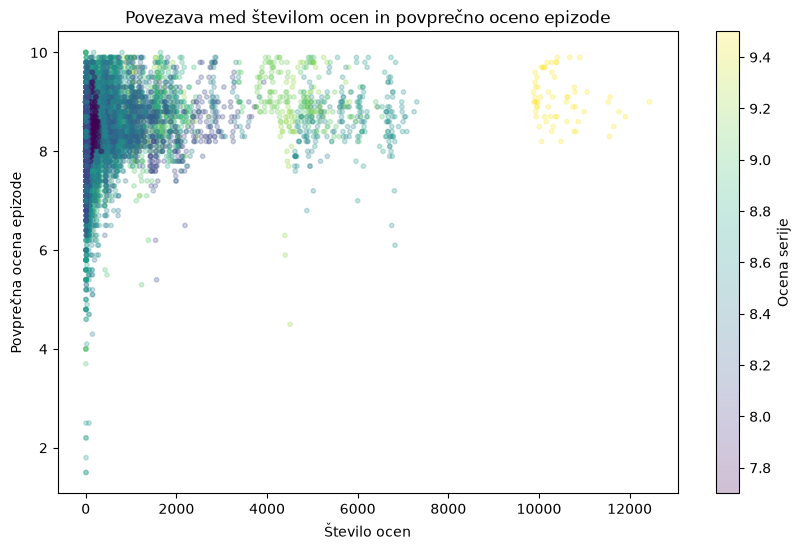

In [165]:
stevilo_ocen = podatki_epizode["community_count"]
povprecna_ocena = podatki_epizode["vote_average"]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(stevilo_ocen, povprecna_ocena, s=10, c=podatki_epizode["ocena_serije"], alpha=0.25)
plt.title("Povezava med številom ocen in povprečno oceno epizode")
plt.xlabel("Število ocen")  
plt.ylabel("Povprečna ocena epizode")
plt.colorbar(scatter, label="Ocena serije")

Moja hipoteza je bila, da bodo največkrat ocenjene epizode imele tudi eno izmed najboljših povprečnih ocen. Kasneje sem dodala še barvno skalo, s pomočjo katere je možno razbrati, da največrat ocenjene epizode vse pripadajo tudi najboljše ocenjenim serijam. 

## Po serijah

### Vrstni red serij in dolžina snemanja

Text(0, 0.5, 'Trajanje serije (v letih)')

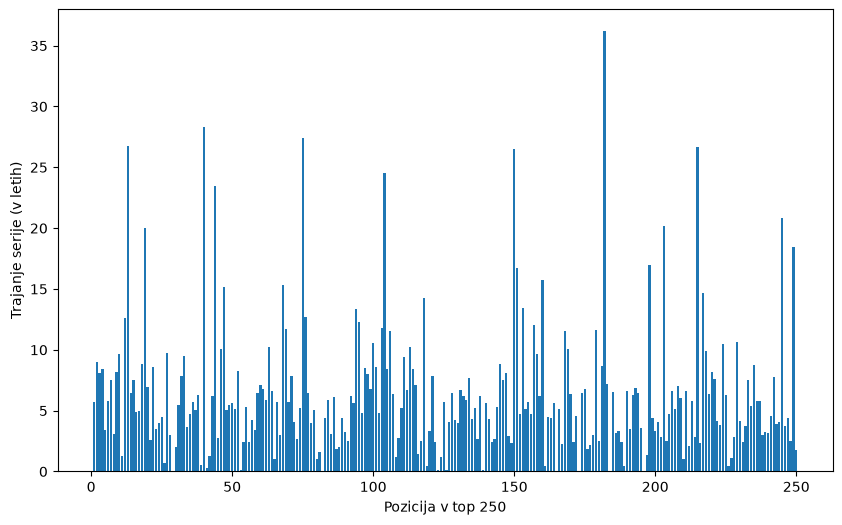

In [166]:
dolzina_snemanja = pd.to_datetime(podatki_serije["Najnovejša_epizoda"]) - pd.to_datetime(podatki_serije["Prva_epizoda"])
pozicija = podatki_serije["Pozicija"]

dolzina_snemanja = dolzina_snemanja.dt.days / 365.25

plt.figure(figsize=(10, 6))
plt.bar(pozicija, dolzina_snemanja)
plt.xlabel("Pozicija v top 250")  
plt.ylabel("Trajanje serije (v letih)")

### Čas izdaje epizode
Spodnji graf prikazuje deleže epizod, po času izdaje ob tem 2015 vsebuje vse epizode izdane med 2015 in 2020.

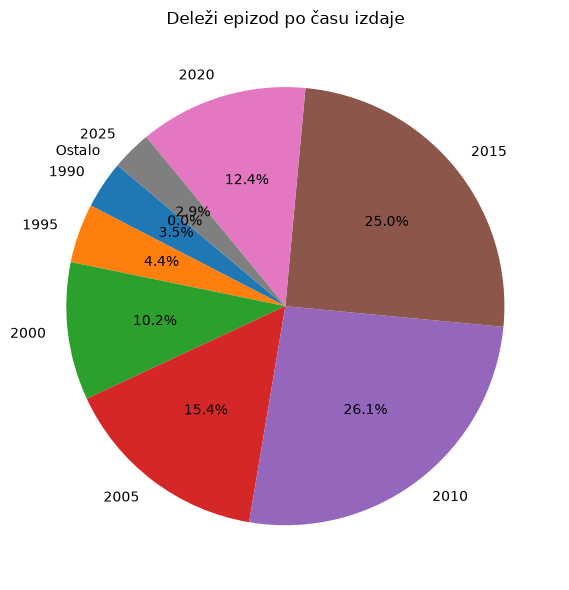

In [167]:
podatki_epizode["leto_epizode"] = podatki_epizode["air_date"].str[:4].astype(float) // 5 * 5
podatki_epizode["leto_epizode"] = podatki_epizode["leto_epizode"].astype(int)

intervali = (
    podatki_epizode.groupby("leto_epizode")["vote_average"]
    .count()
    .sort_index()
)

meja = intervali.sum() * 0.01
intervali = intervali[intervali >= meja]
intervali["Ostalo"] = intervali[intervali < meja].sum()

plt.figure(figsize=(6, 6))
plt.pie(intervali, labels=intervali.index, autopct="%1.1f%%", startangle=140, textprops={"fontsize": 10})
plt.title("Deleži epizod po času izdaje")
plt.tight_layout()
plt.show()

### Dolžina snemanja / razlika v minimalni in maksimalni oceni

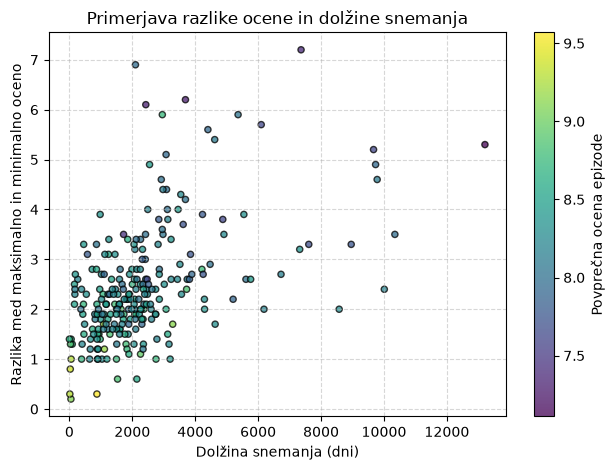

In [168]:

podatki_serije["Dolzina_snemanja"] = pd.to_datetime(podatki_serije["Najnovejša_epizoda"]) - pd.to_datetime(podatki_serije["Prva_epizoda"])
podatki_serije["Dolzina_snemanja"] = podatki_serije["Dolzina_snemanja"].dt.days 
podatki_serije["Razlika_ocena"] = podatki_serije["Maksimalna_ocena"] - podatki_serije["Minimalna_ocena"]

scatter_2 = plt.scatter(
    podatki_serije["Dolzina_snemanja"],
    podatki_serije["Razlika_ocena"],
    s=20,
    c=podatki_serije["Povprecna_ocena_epizode"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black"
)

plt.title("Primerjava razlike ocene in dolžine snemanja")
plt.xlabel("Dolžina snemanja (dni)")
plt.ylabel("Razlika med maksimalno in minimalno oceno")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter_2, label="Povprečna ocena epizode")
plt.tight_layout()
plt.show()

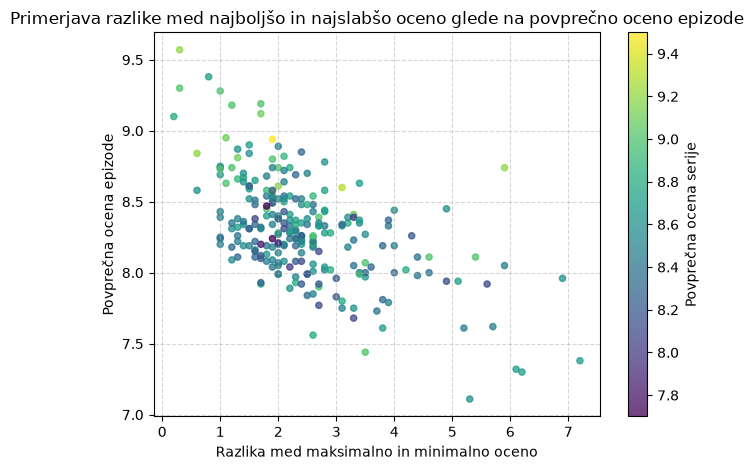

In [175]:

podatki_serije["Razlika_ocena"] = podatki_serije["Maksimalna_ocena"] - podatki_serije["Minimalna_ocena"]

scatter = plt.scatter(
    podatki_serije["Razlika_ocena"],
    podatki_serije["Povprecna_ocena_epizode"],
    s=20,
    c=podatki_serije["Povprecna_ocena_sezone"],
    cmap="viridis",
    alpha=0.75
)

plt.title("Primerjava razlike med najboljšo in najslabšo oceno glede na povprečno oceno epizode")
plt.xlabel("Razlika med maksimalno in minimalno oceno")
plt.ylabel("Povprečna ocena epizode")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter, label="Povprečna ocena serije")
plt.tight_layout()
plt.show()

### Aktivnost 
Ali je serija aktivna?

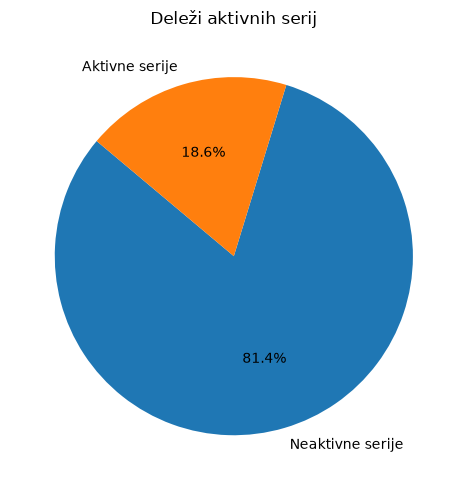

In [ ]:
podatki_serije["Najnovejša_epizoda"] = pd.to_datetime(podatki_serije["Najnovejša_epizoda"])
podatki_serije["Aktivna_serija"] = podatki_serije["Najnovejša_epizoda"].dt.year >= 2025
pie_data = podatki_serije["Aktivna_serija"].value_counts()
pie_labels = ["Neaktivne serije", "Aktivne serije"]

plt.figure(figsize=(5, 5))
plt.pie(pie_data, labels=pie_labels, autopct="%1.1f%%", startangle=140, textprops={"fontsize": 10})
plt.title("Deleži aktivnih serij")
plt.tight_layout()
plt.show()

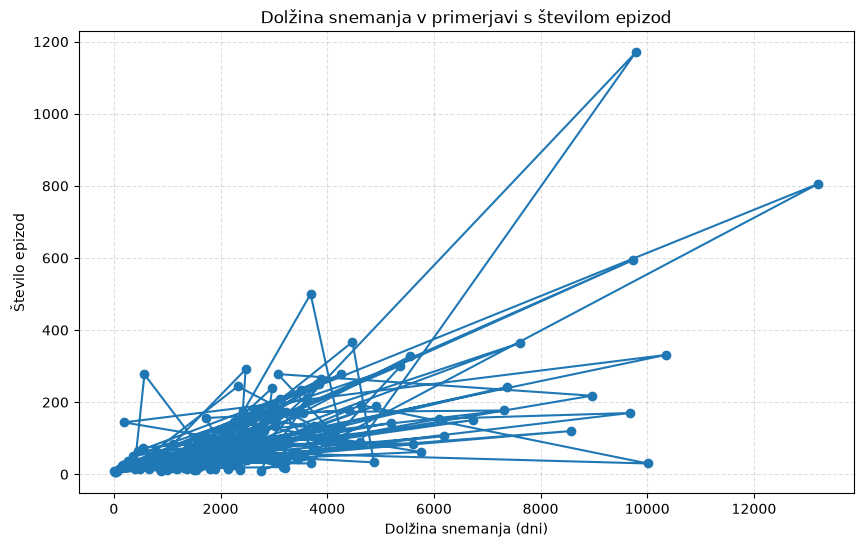

In [ ]:
dolzina_snemanja = (
    pd.to_datetime(podatki_serije["Najnovejša_epizoda"])
    - pd.to_datetime(podatki_serije["Prva_epizoda"])
).dt.days

stevilo_epizod = podatki_serije["Stevilo_epizod"]

plt.figure(figsize=(10, 6))
plt.title("Dolžina snemanja v primerjavi s številom epizod")
plt.xlabel("Dolžina snemanja (dni)")
plt.ylabel("Število epizod")
plt.plot(dolzina_snemanja, stevilo_epizod, marker="o")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

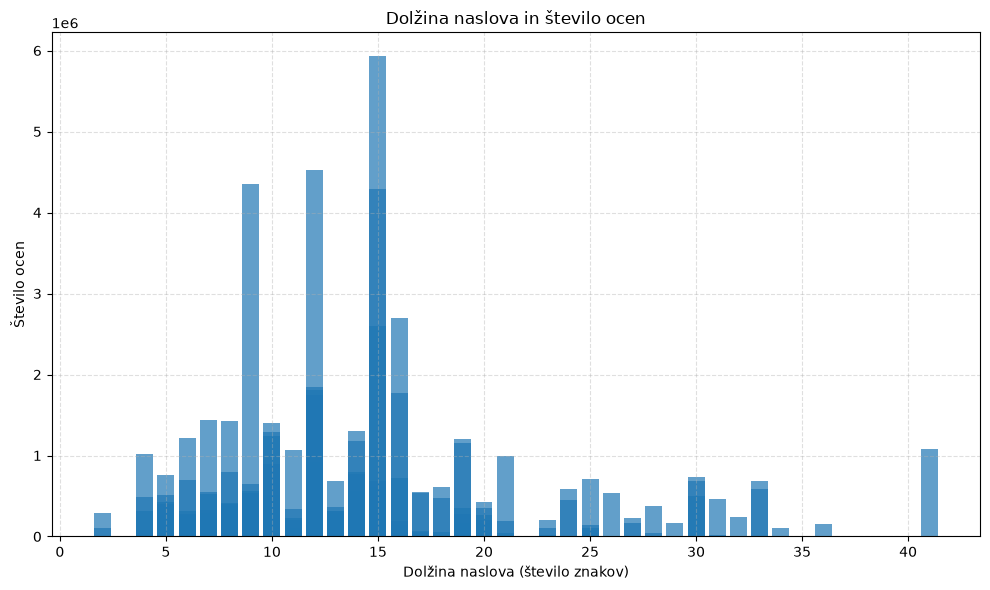

In [ ]:
dolzina_naslova = podatki_serije["Naslov"].str.len()
stevilo_ocen = podatki_serije["Stevilo_ocen_epizod"]

plt.figure(figsize=(10, 6))
plt.bar(dolzina_naslova, stevilo_ocen, alpha=0.7)
plt.xlabel("Dolžina naslova (število znakov)")
plt.ylabel("Število ocen")
plt.title("Dolžina naslova in število ocen")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

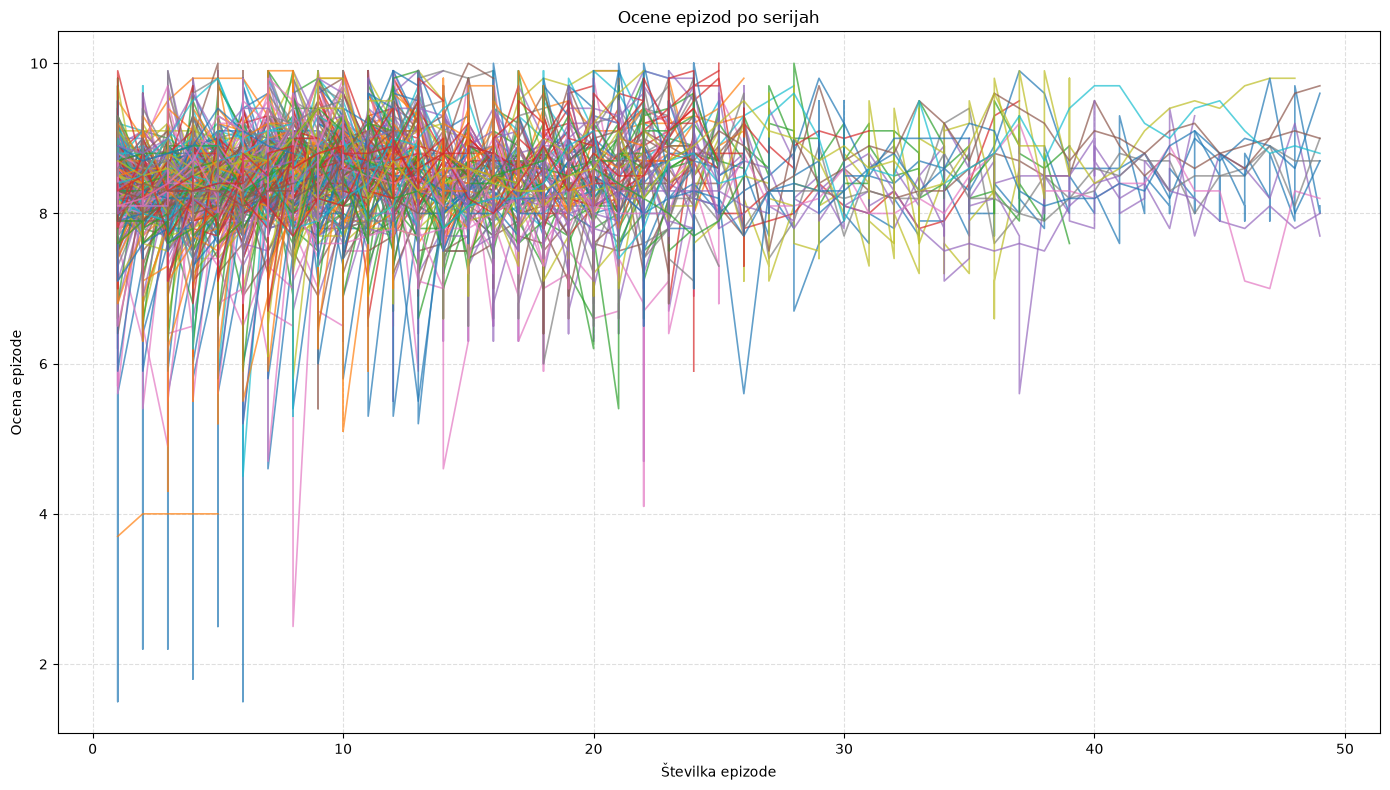

In [181]:
# Vsaka črta predstavlja eno serijo (isti id)
# x os: številka epizode
# y os: ocena epizode

fig, ax = plt.subplots(figsize=(14, 8))

filtered = podatki_epizode[podatki_epizode["episode_number"] < 50]

for show_id, group in (
    filtered
    .sort_values(["id", "episode_number"])
    .groupby("id")
):
    ax.plot(
        group["episode_number"],
        group["vote_average"],
        linewidth=1.2,
        alpha=0.7,
        label=str(show_id)
    )

ax.set_title("Ocene epizod po serijah")
ax.set_xlabel("Številka epizode")
ax.set_ylabel("Ocena epizode")
ax.grid(True, linestyle="--", alpha=0.4)

# Če je serij veliko, legenda lahko prekriva graf; zato je izklopljena
ax.legend([], frameon=False)

plt.tight_layout()
plt.show()

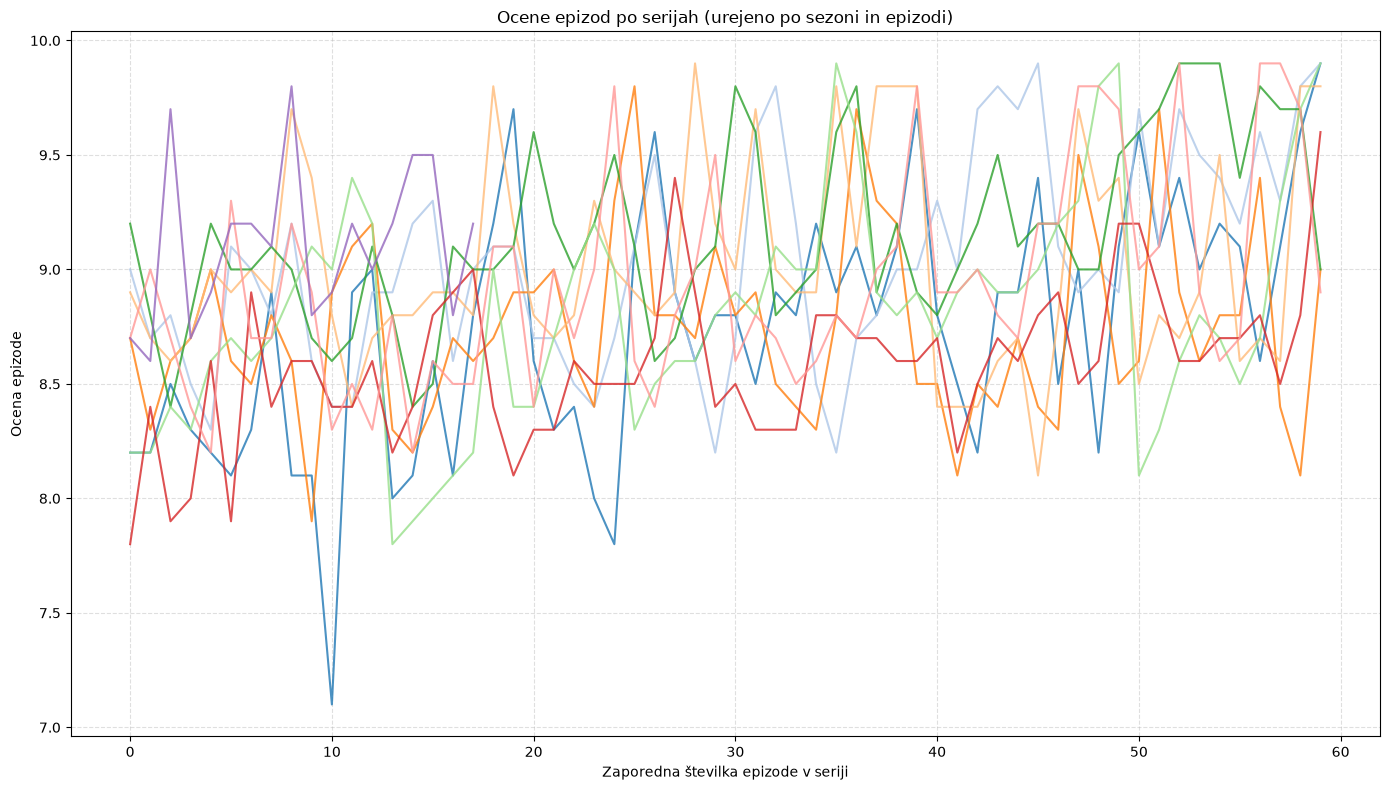

In [193]:
# Sort every show's episodes by season_number, then episode_number
import numpy as np

ordered = (
    podatki_epizode[["id", "season_number", "episode_number", "vote_average"]]
    .sort_values(["id", "season_number", "episode_number"], kind="mergesort")
    .copy()
)

show_ids = podatki_epizode.loc[podatki_epizode["pozicija"] < 10, "id"].unique()
ordered = ordered[ordered["id"].isin(show_ids)].copy()

ordered = ordered.groupby("id", group_keys=False).head(60)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.get_cmap("tab20")

for i, (show_id, group) in enumerate(ordered.groupby("id")):
    # x = position of each episode in that show's ordered sequence
    x = np.arange(len(group))
    ax.plot(
        x,
        group["vote_average"].to_numpy(),
        color=cmap(i % cmap.N),
        linewidth=1.5,
        alpha=0.8
    )

ax.set_title("Ocene epizod po serijah (urejeno po sezoni in epizodi)")
ax.set_xlabel("Zaporedna številka epizode v seriji")
ax.set_ylabel("Ocena epizode")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend([], frameon=False)
plt.tight_layout()
plt.show()